# Malaysia MOH Health Data

This notebook demonstrates how to access public health datasets from the **Malaysia Ministry of Health (MOH)** via the [data.gov.my](https://data.gov.my/) open data portal.

**Data Sources:**
- **Portal:** [data.gov.my/data-catalogue?category=healthcare](https://data.gov.my/data-catalogue?category=healthcare)
- **Storage:** `https://storage.data.gov.my/healthcare/` (Parquet)
- **API Docs:** [developer.data.gov.my](https://developer.data.gov.my/)

**Coverage:**
- **Geographic:** National + 16 Malaysian states
- **Temporal:** Varies by dataset (daily, annual, point-in-time)
- **Topics:** COVID-19, STDs, immunisation, hospital infrastructure, blood/organ donations

**Requirements:**
```bash
pip install pandas matplotlib seaborn epidatasets
```

## 1. Setup and Imports

In [1]:
import warnings
from datetime import datetime

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
%matplotlib inline

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)

print(f"Imports completed. {datetime.now().strftime('%Y-%m-%d %H:%M')}")

Imports completed. 2026-06-22 15:59


## 2. Initialize the Accessor

In [2]:
from epidatasets.sources.malaysia_moh import MalaysiaMOHAccessor

moh = MalaysiaMOHAccessor()

print(f"Source      : {moh.source_name}")
print(f"Description : {moh.source_description}")
print(f"Portal      : {moh.source_url}")

Source      : malaysia_moh
Description : Public health data from the Ministry of Health Malaysia via data.gov.my: COVID-19 cases, STDs, immunisation, hospital beds, healthcare staff, blood donations, organ pledges, and PeKaB40 health screenings.
Portal      : https://data.gov.my/data-catalogue?category=healthcare


In [3]:
countries = moh.list_countries()
print(countries.to_string(index=False))

print(f"\nMalaysian states:")
display(moh.list_states())

country_code country_name
          MY     Malaysia

Malaysian states:


,state
0,Malaysia
1,Johor
2,Kedah
3,Kelantan
4,Melaka
5,Negeri Sembilan
6,Pahang
7,Perak
8,Perlis
9,Pulau Pinang


## 3. COVID-19 Cases

Daily COVID-19 cases at national and state level, with details on imported, recovered, active, and cluster-related cases.

In [4]:
covid = moh.get_covid_cases(state='Malaysia')
print(f"National COVID-19 records: {len(covid)}")
display(covid.head())

National COVID-19 records: 1954


,date,state,cases_new,cases_import,cases_recovered,cases_active,cases_cluster
0,2020-01-25,Malaysia,4,4,0,4,0
1,2020-01-26,Malaysia,0,0,0,4,0
2,2020-01-27,Malaysia,0,0,0,4,0
3,2020-01-28,Malaysia,0,0,0,4,0
4,2020-01-29,Malaysia,3,3,0,7,0


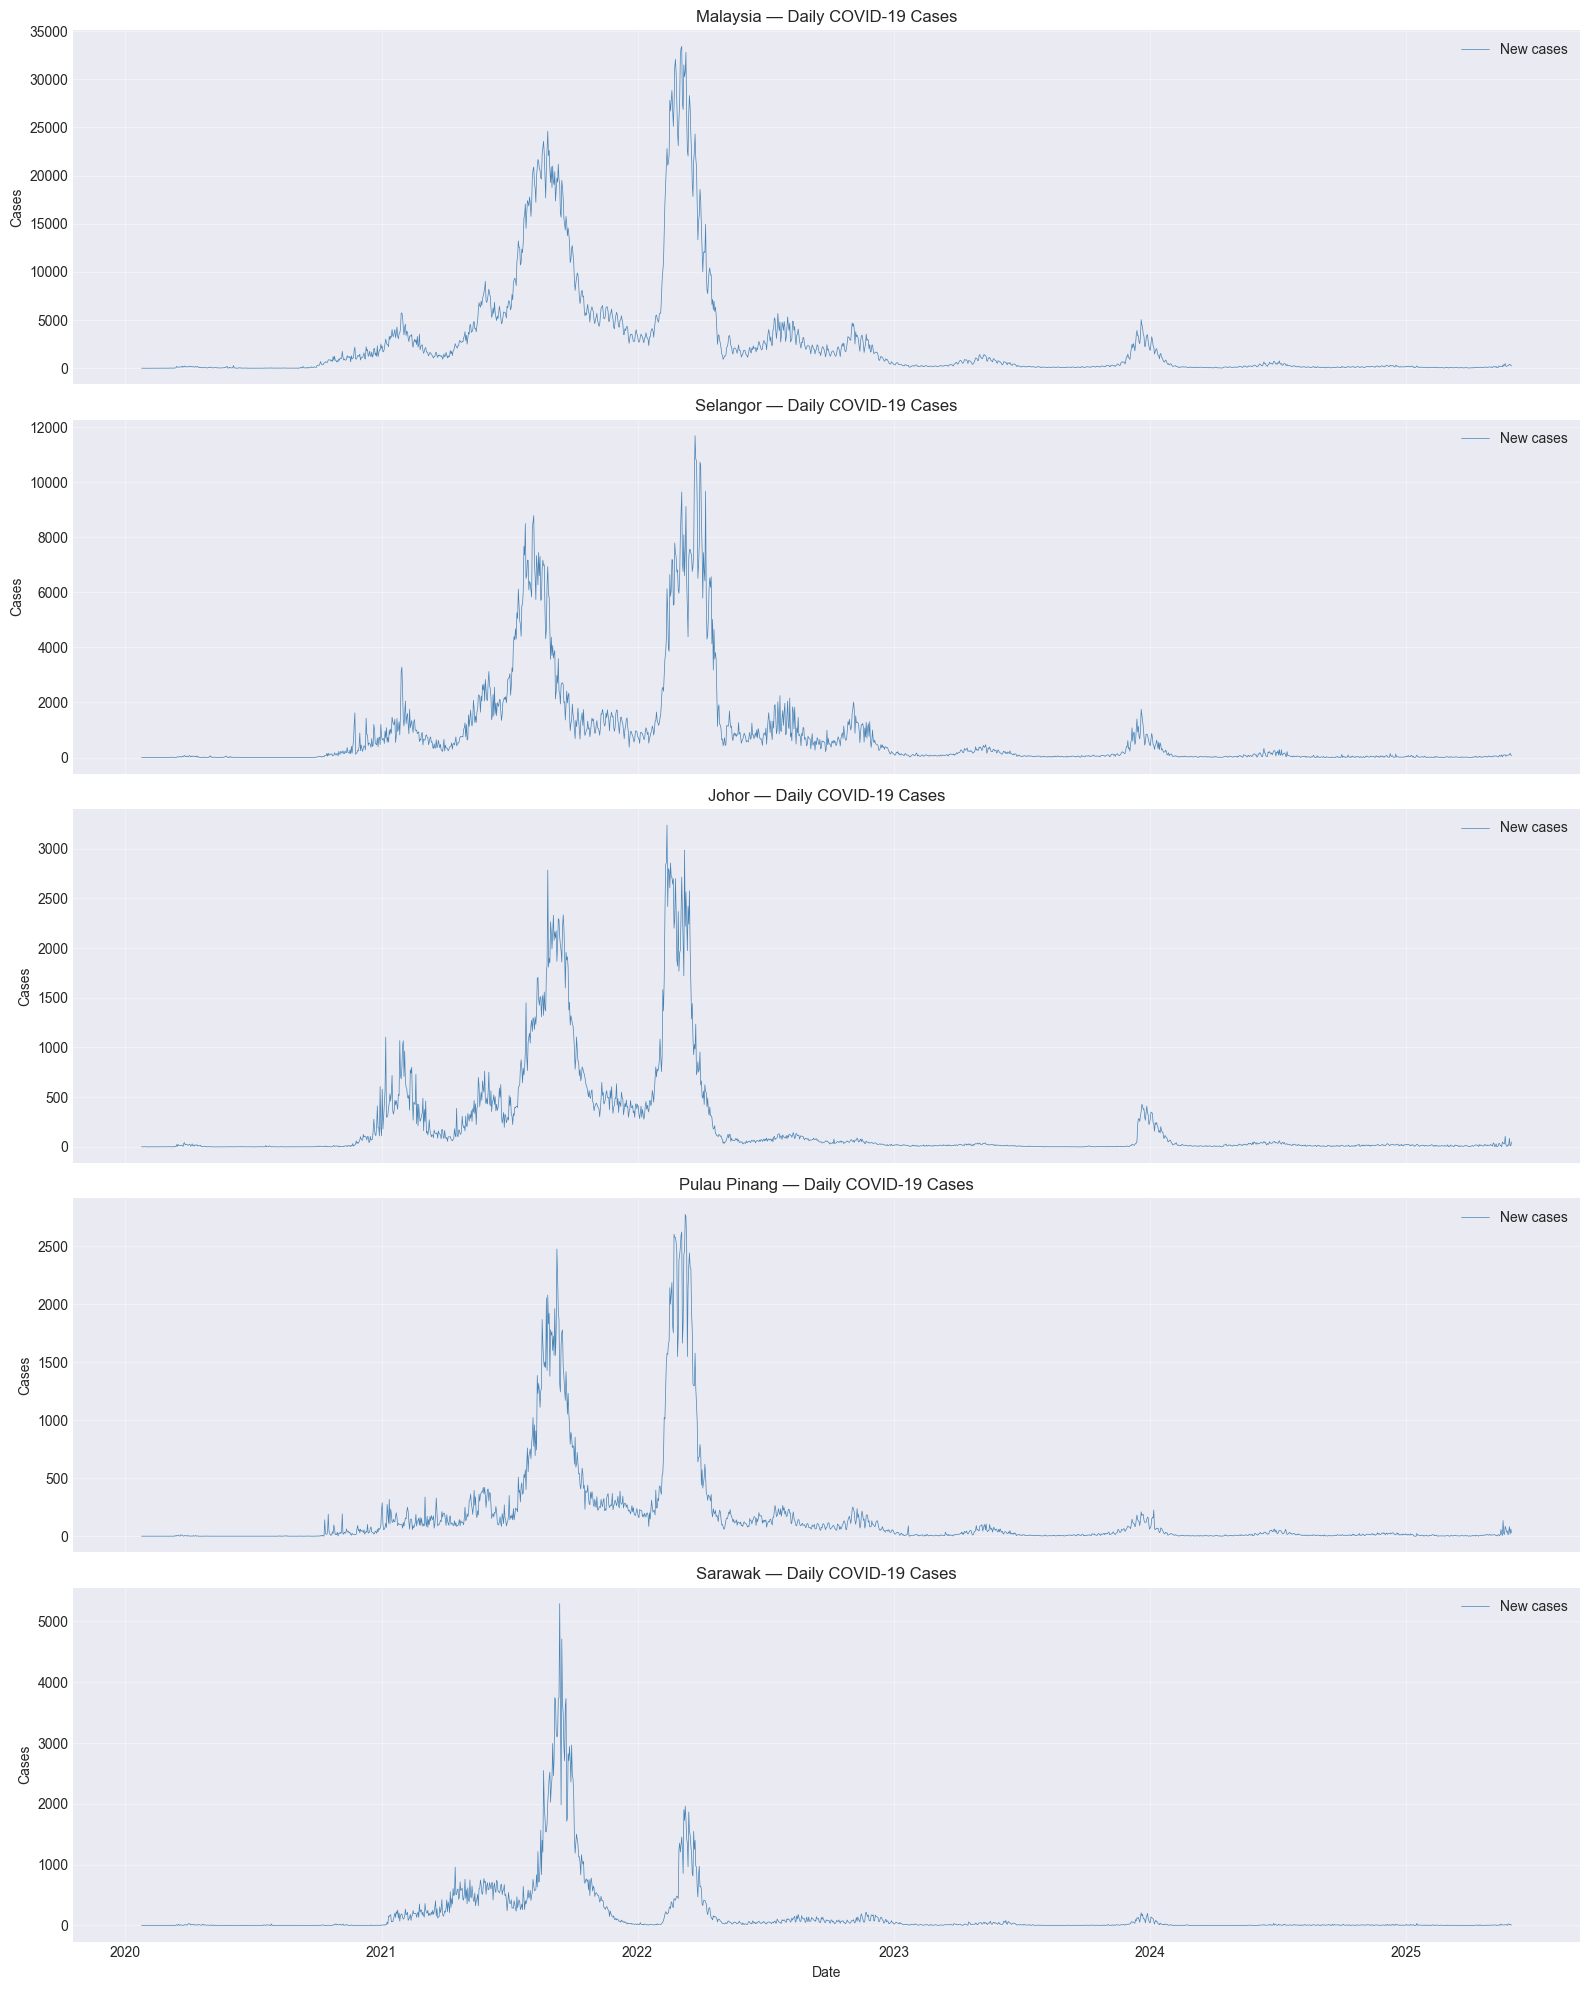

In [5]:
# Yearly evolution of cases by key states
states = ['Malaysia', 'Selangor', 'Johor', 'Pulau Pinang', 'Sarawak']

fig, axes = plt.subplots(len(states), 1, figsize=(16, 4 * len(states)), sharex=True)
for ax, state in zip(axes, states):
    sub = moh.get_covid_cases(state=state)
    ax.plot(sub['date'], sub['cases_new'], linewidth=0.5, color='steelblue', label='New cases')
    ax.set_title(f'{state} — Daily COVID-19 Cases')
    ax.set_ylabel('Cases')
    ax.legend()
axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

### Cases by age group

Breakdown of daily cases into children, adolescents, adults, and elderly.

In [6]:
age = moh.get_covid_cases_age(state='Malaysia')
print(f"Age-group records: {len(age)}")
display(age.head())

Age-group records: 1954


,date,state,cases_child,cases_adolescent,cases_adult,cases_elderly,cases_0_4,cases_5_11,cases_12_17,cases_18_29,cases_30_39,cases_40_49,cases_50_59,cases_60_69,cases_70_79,cases_80
0,2020-01-25,Malaysia,0,0,1,0,0,0,0,0,0,1,0,0,0,0
1,2020-01-26,Malaysia,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2020-01-27,Malaysia,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,2020-01-28,Malaysia,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,2020-01-29,Malaysia,1,0,2,0,1,0,0,0,1,0,1,0,0,0


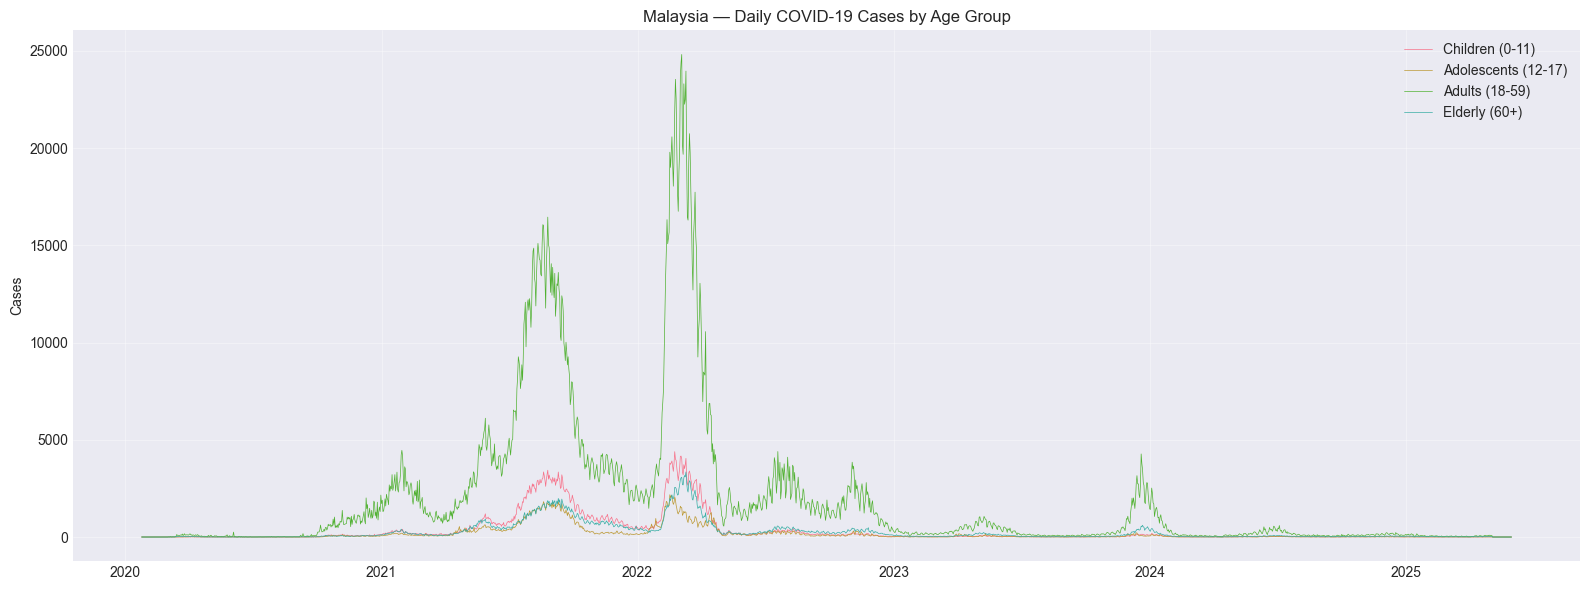

In [7]:
fig, ax = plt.subplots(figsize=(16, 6))
for col, label, ls in [
    ('cases_child', 'Children (0-11)', '-'),
    ('cases_adolescent', 'Adolescents (12-17)', '-'),
    ('cases_adult', 'Adults (18-59)', '-'),
    ('cases_elderly', 'Elderly (60+)', '-'),
]:
    ax.plot(age['date'], age[col], linewidth=0.5, label=label)
ax.set_title('Malaysia — Daily COVID-19 Cases by Age Group')
ax.set_ylabel('Cases')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Sexually Transmitted Diseases

Annual STD cases by state — HIV, AIDS, chancroid, gonorrhea, syphilis.

Total cases by disease:


disease
syphillis    41528
hiv          38574
gonorrhea    30252
aids         12914
chancroid       26
Name: cases, dtype: int64

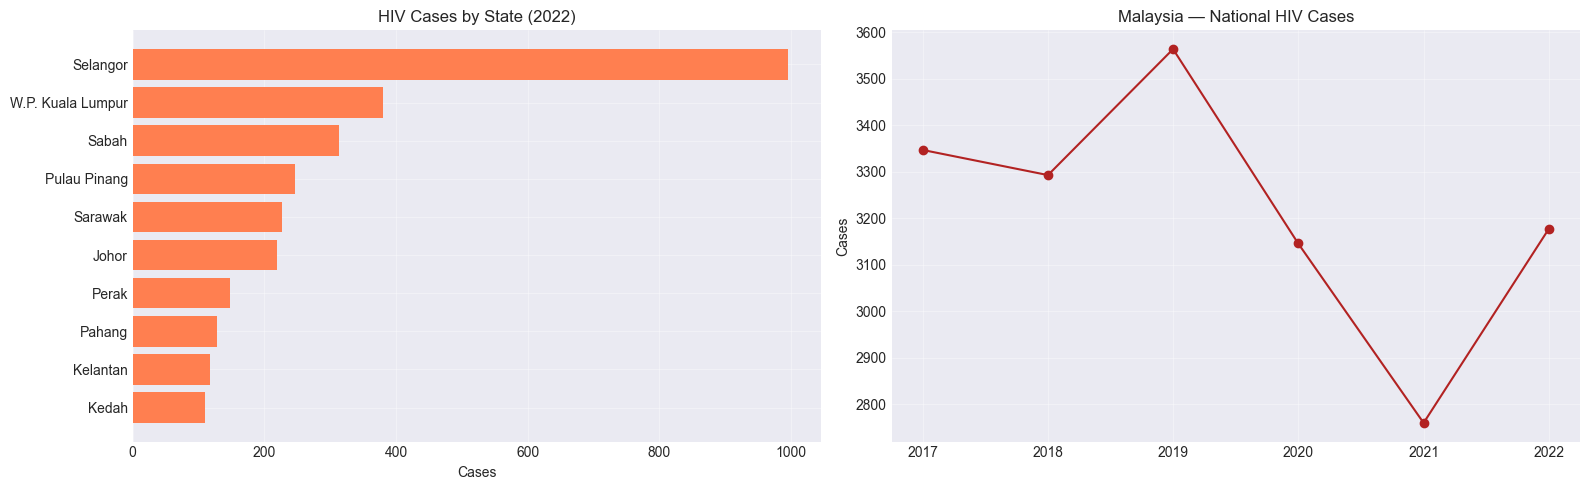

In [8]:
std = moh.get_std_cases()
disease_summary = std.groupby('disease')['cases'].sum().sort_values(ascending=False)
print("Total cases by disease:")
display(disease_summary)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# HIV by state (latest year)
hiv = std[(std['disease'].str.lower() == 'hiv') & (std['state'] != 'Malaysia')]
latest_year = hiv['date'].max()
hiv_latest = hiv[hiv['date'] == latest_year].nlargest(10, 'cases')
axes[0].barh(hiv_latest['state'][::-1], hiv_latest['cases'][::-1], color='coral')
axes[0].set_title(f'HIV Cases by State ({latest_year.year})')
axes[0].set_xlabel('Cases')

# National yearly trend
nat_hiv = std[(std['disease'].str.lower() == 'hiv') & (std['state'] == 'Malaysia')]
axes[1].plot(nat_hiv['date'], nat_hiv['cases'], marker='o', color='firebrick')
axes[1].set_title('Malaysia — National HIV Cases')
axes[1].set_ylabel('Cases')

plt.tight_layout()
plt.show()

## 5. Hospital Infrastructure

Public-sector hospital beds by state and type, and healthcare staff distribution.

In [9]:
beds = moh.get_hospital_beds(state='Malaysia', hospital_type='all')
latest_beds = beds[beds['date'] == beds['date'].max()]
print(f"Latest hospital beds data ({beds['date'].max().strftime('%Y')}):")
display(latest_beds[['state', 'beds']].head())

Latest hospital beds data (2022):


,state,beds
7,Malaysia,49985


Latest healthcare staff data:


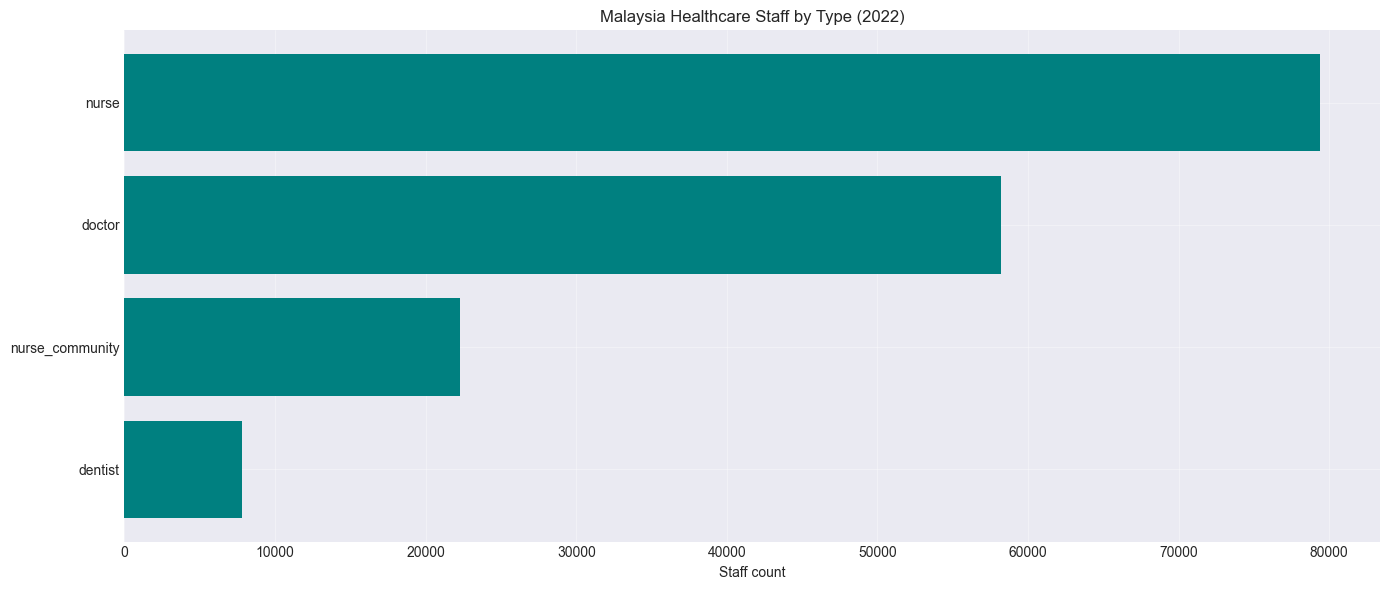

In [10]:
staff = moh.get_healthcare_staff(state='Malaysia', staff_type='all')
print(f"Latest healthcare staff data:")

# Staff by type (latest year)
staff_types = moh.get_healthcare_staff(state='Malaysia')
latest_year = staff_types['date'].max()
staff_latest = staff_types[
    (staff_types['date'] == latest_year) & (staff_types['type'] != 'all')
].nlargest(10, 'staff')

fig, ax = plt.subplots()
ax.barh(staff_latest['type'][::-1], staff_latest['staff'][::-1], color='teal')
ax.set_title(f'Malaysia Healthcare Staff by Type ({latest_year.year})')
ax.set_xlabel('Staff count')
plt.tight_layout()
plt.show()

## 6. Health Programmes

Daily blood donations, organ donation pledges, and PeKaB40 health screenings.

In [11]:
blood = moh.get_blood_donations(blood_type='all')
print(f"Blood donation records: {len(blood)}")
display(blood.tail())

Blood donation records: 7477


,date,blood_type,donations
7472,2026-06-17,all,1656
7473,2026-06-18,all,1341
7474,2026-06-19,all,1111
7475,2026-06-20,all,1516
7476,2026-06-21,all,2551


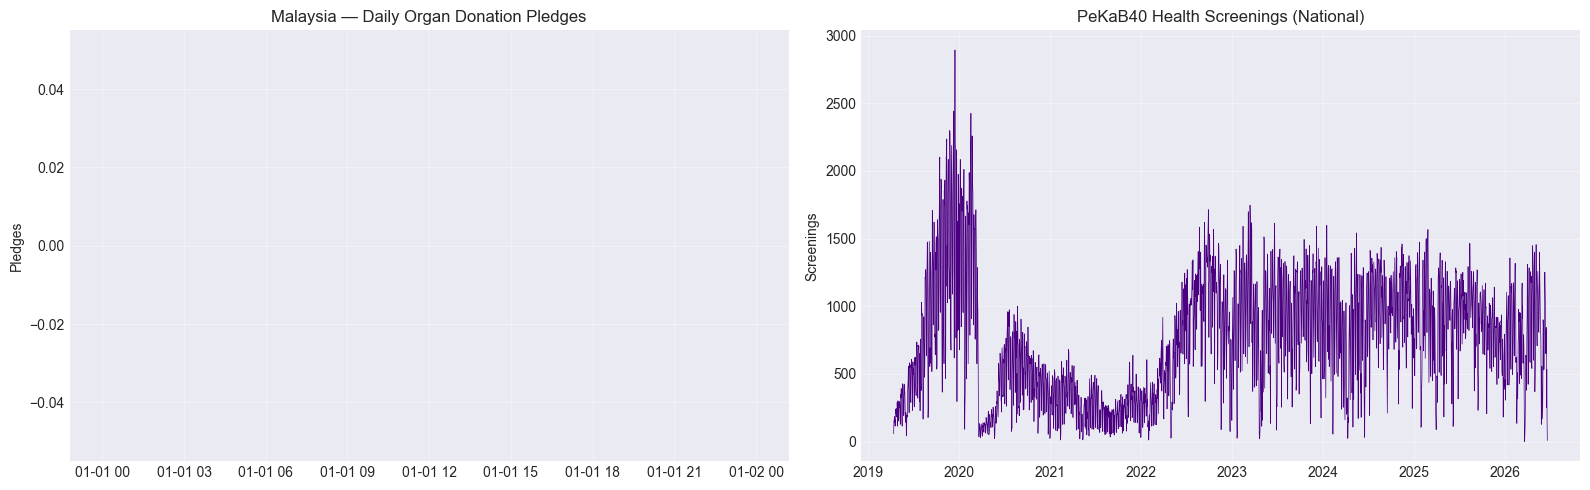

In [12]:
pledges = moh.get_organ_pledges_state(state='Malaysia')
pekab40 = moh.get_pekab40_screenings()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(pledges['date'], pledges['pledges'], linewidth=0.5, color='darkgreen')
axes[0].set_title('Malaysia — Daily Organ Donation Pledges')
axes[0].set_ylabel('Pledges')

axes[1].plot(pekab40['date'], pekab40['screenings'], linewidth=0.5, color='indigo')
axes[1].set_title('PeKaB40 Health Screenings (National)')
axes[1].set_ylabel('Screenings')

plt.tight_layout()
plt.show()

## 7. Summary

| Method | Description |
|--------|-------------|
| `get_covid_cases(state)` | Daily COVID-19 cases by state |
| `get_covid_cases_age(state)` | Daily COVID-19 cases by age group & state |
| `get_std_cases(disease, state)` | Annual STD cases by disease and state |
| `get_infant_immunisation(disease)` | Infant immunisation coverage rates |
| `get_hospital_beds(state, type)` | Hospital beds by state, district, hospital type |
| `get_healthcare_staff(state, type)` | Healthcare staff by state and staff type |
| `get_blood_donations(blood_type)` | Daily blood donations by blood type |
| `get_organ_pledges()` | Daily organ donation pledges (national) |
| `get_organ_pledges_state(state)` | Organ pledges by state |
| `get_pekab40_screenings()` | PeKaB40 health screenings (national) |
| `get_pekab40_screenings_state(state)` | PeKaB40 screenings by state |

**Related notebooks:**
- [Singapore MOH](26_Singapore_MOH_Infectious_Disease.ipynb) — similar ministry-of-health bulletin data.
- [WHO Global Health Data](02_who_global_health_data.ipynb) — cross-country comparisons.